# Tensile Test: from machine file to RDF

> **This is notebook 2 of 2.** It assumes you have already worked through
> [Notebook 1](1_tensile_test_workflow.ipynb), which explains the schema
> structure, the OO-LD format, and SHACL validation using a hand-crafted
> input file. Here, the same pipeline runs end-to-end from a real instrument
> export — no manual data entry required.

**You only need to edit one cell:** Step 0 below. Everything else is automatic.

**What you get back:**
- An RDF graph with test metadata (conditions, standard, temperature) and
  typed column descriptors, ready to publish to a knowledge graph
- A pandas DataFrame with the full time-series data, ready to plot or analyse

The measurement *values* never become RDF triples. Only the column
descriptors (ontology class and unit) are stored in the graph. This keeps the
graph compact while making the data findable and self-describing.

```
Instrument export file
  │
  ├─ metadata rows  ──► Transformer ──► OO-LD ──► RDF graph
  │                     (same transform as notebook 1)
  └─ data rows  ─────► pandas DataFrame
```

## Supported file format

This notebook uses the **Zwick/Roell extractor**. For other instruments, swap
in a different extractor; the rest of the notebook stays unchanged. See
`semantic-transformers/parsers/` for available parsers and
`docs/adding-a-parser.md` for how to add one.

## Environment setup

```bash
python3 -m venv .venv
source .venv/bin/activate
pip install jupyterlab
pip install -e /path/to/semantic-transformers
jupyter lab
```


In [23]:
# Install dependencies (run once; skip if already installed)
%pip install -q jsonata-python rdflib pyshacl pyyaml pandas

Note: you may need to restart the kernel to use updated packages.


In [24]:
import sys, json, pathlib, rdflib, pyshacl
from importlib.metadata import version

print("Python        :", sys.executable)
print("rdflib        ", version("rdflib"))
print("pyshacl       ", version("pyshacl"))

HERE       = pathlib.Path().resolve()             # docs/
SCHEMA     = HERE.parent                          # tensile-test/TTO/
STORE_ROOT = SCHEMA.parents[3]                    # semantic-schemas/
CHAR_BASE  = STORE_ROOT / 'schemas' / 'characterization' / 'step' / 'PMDCo'

# Make the parsers/ folder importable
# semantic-transformers is a sibling repository of semantic-schemas
TRANSFORMERS = STORE_ROOT.parent / 'semantic-transformers'
sys.path.insert(0, str(TRANSFORMERS / 'parsers' / 'characterization' / 'tensile-test' / 'zwick'))
from extractor import ZwickExtractor
from semantic_transformers import Transformer

Python        : /root/semantic-dataspace/.venv/bin/python3
rdflib         7.6.0
pyshacl        0.31.0


## Step 0, Point to your file

Edit the line below and run all cells. That is all that is needed for a basic run.

| Variable | What to put here |
|---|---|
| `csv_file` | Path to your Zwick export (`.TXT` or `.csv`) |

`test_name` is optional, if omitted the file name is used.

In [25]:
# Sample file bundled with semantic-transformers — replace with your own file path:
csv_file  = TRANSFORMERS / 'tests' / 'data' / 'DX56_D_FZ2_WR00_43.TXT'
test_name = None   # optional — set to a string to override the file-name default


## Step 1, Extract, transform, and build the RDF graph

The `Transformer` does three things in one call:

1. **Extract**, the Zwick extractor reads the CSV, separates metadata from
   time-series data, and maps the metadata to the simplified JSON format that
   the schema transform expects.
2. **Transform**, the JSONata expression in `simplified/transform.jsonata`
   converts the simplified JSON into a structured OO-LD document.
3. **Build RDF**, the OO-LD document is parsed into an RDF graph using the
   ontology context from `specs/schema.oold.yaml`, then one lightweight
   descriptor node per measurement column is added.

The context maps every field in the OO-LD document to its precise ontology IRI, for example:

| JSON field | Ontology IRI |
|---|---|
| `type` | `rdf:type` |
| `has_specified_input` | `OBI_0000293` |
| `measured_properties` | `OBI_0000299` (has_specified_output) |
| `result_value` | `OBI_0001937` (has_specified_numeric_value) |
| `result_unit` | `IAO_0000039` (has_measurement_unit_label) |

In [26]:
transformer = Transformer(
    extractor = ZwickExtractor(),
    transform = SCHEMA / 'simplified' / 'transform.jsonata',
    context   = SCHEMA / 'specs'      / 'schema.oold.yaml',
)

overrides = {}
if test_name:
    overrides['test_name'] = test_name

result = transformer.run(csv_file, **overrides)

print('OO-LD document (intermediate):')
print(json.dumps(result.oold_doc, indent=2))

OO-LD document (intermediate):
{
  "conforms_to": "https://github.com/semantic-dataspace/semantic-schemas/tree/main/schemas/characterization/tensile-test/TTO/#v1.0.0",
  "type": "tto:TensileTest",
  "id": "tensile-test-dx56-d-fz2-wr00-43",
  "label": "DX56_D_FZ2_WR00_43",
  "has_specified_input": [],
  "has_process_condition": [
    {
      "type": "pmdco:PMD_0000013",
      "id": "tensile-test-dx56-d-fz2-wr00-43-condition-standard",
      "parameter_label": "Test Standard",
      "parameter_unit": "ISO 6892-1"
    },
    {
      "type": "pmdco:PMD_0000013",
      "id": "tensile-test-dx56-d-fz2-wr00-43-condition-strain-rate",
      "parameter_label": "Strain Rate",
      "parameter_value": 0.1,
      "parameter_unit": "mm/s"
    },
    {
      "type": "pmdco:PMD_0000013",
      "id": "tensile-test-dx56-d-fz2-wr00-43-condition-temperature",
      "parameter_label": "Temperature",
      "parameter_value": 22.0,
      "parameter_unit": "\u00b0C"
    }
  ]
}


## Step 2, Explore the time-series data

The raw measurement columns are in `result.dataframe`, a standard pandas
DataFrame. You can plot, filter, or compute derived quantities (yield strength,
Young's modulus, …) using any tool you like.

In [27]:
df = result.dataframe
print(f'{len(df)} rows  ×  {len(df.columns)} columns\n')
print(df.head(10).to_string(index=False))

82 rows  ×  6 columns

 Prüfzeit  Standardkraft  Traversenweg absolut  Standardweg  Breitenänderung  Dehnung
      0.0            0.0                 0.000        0.000           -0.000     0.00
      0.1          807.6                 0.011        0.010           -0.001     0.01
      0.2         1615.2                 0.023        0.020           -0.001     0.02
      0.3         2422.8                 0.034        0.030           -0.002     0.04
      0.5         3230.4                 0.045        0.040           -0.003     0.05
      0.6         4038.1                 0.056        0.050           -0.004     0.06
      0.7         4845.7                 0.068        0.059           -0.004     0.07
      0.8         5653.3                 0.079        0.069           -0.005     0.09
      0.8         5721.1                 0.081        0.071           -0.005     0.09
      0.8         5032.0                 0.082        0.073           -0.006     0.09


In [28]:
# Semantic annotations stored in the graph — one row per measurement column
print(f'{"Column":<25}  {"Ontology class":<50}  QUDT unit')
print('-' * 100)
for col in df.columns:
    iri  = result.column_iris.get(col,  '—')
    unit = result.column_units.get(col, '—')
    print(f'{col:<25}  {iri:<50}  {unit}')

Column                     Ontology class                                      QUDT unit
----------------------------------------------------------------------------------------------------
Prüfzeit                   https://w3id.org/pmd/tto/TestTime                   http://qudt.org/vocab/unit/SEC
Standardkraft              https://w3id.org/pmd/tto/StandardForce              http://qudt.org/vocab/unit/N
Traversenweg absolut       https://w3id.org/pmd/tto/AbsoluteCrossheadTravel    http://qudt.org/vocab/unit/MilliM
Standardweg                https://w3id.org/pmd/tto/Extension                  http://qudt.org/vocab/unit/MilliM
Breitenänderung            https://w3id.org/pmd/tto/WidthChange                http://qudt.org/vocab/unit/MilliM
Dehnung                    https://w3id.org/pmd/tto/Elongation                 http://qudt.org/vocab/unit/MilliM


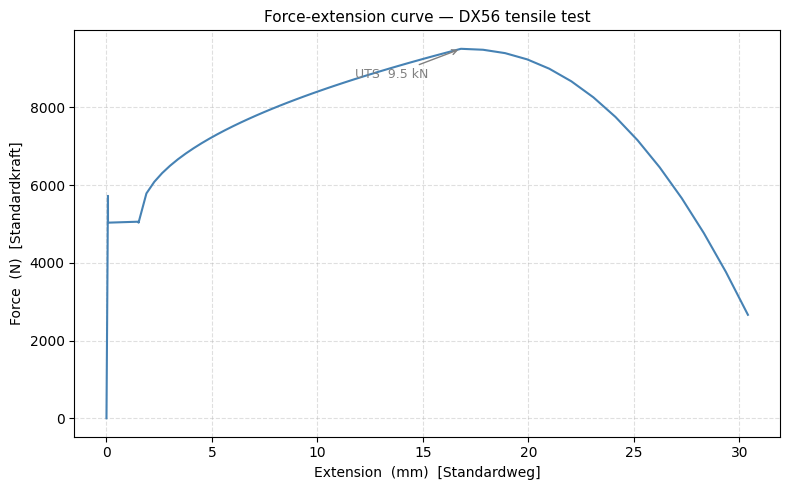

Columns used: extension='Standardweg', force='Standardkraft'
(looked up by TTO IRI, not by German column name)


In [29]:
# Force-extension curve, driven by ontology IRIs
# The column names come from result.column_iris, so this cell works
# with any extractor that follows the TTO schema — not just Zwick.
try:
    import matplotlib.pyplot as plt

    TTO = 'https://w3id.org/pmd/tto/'
    iri_to_col = {iri: col for col, iri in result.column_iris.items()}

    ext_col   = iri_to_col.get(TTO + 'Extension')
    force_col = iri_to_col.get(TTO + 'StandardForce')

    if ext_col and force_col:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(df[ext_col], df[force_col], color='steelblue', linewidth=1.5)

        # Annotate key regions
        f_max_idx = df[force_col].idxmax()
        ax.annotate(
            f'UTS  {df[force_col].max() / 1000:.1f} kN',
            xy=(df[ext_col][f_max_idx], df[force_col][f_max_idx]),
            xytext=(df[ext_col][f_max_idx] - 5, df[force_col][f_max_idx] * 0.92),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray',
        )

        ax.set_xlabel(f'Extension  (mm)  [{ext_col}]', fontsize=10)
        ax.set_ylabel(f'Force  (N)  [{force_col}]', fontsize=10)
        ax.set_title('Force-extension curve — DX56 tensile test', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()
        print(f'Columns used: extension={ext_col!r}, force={force_col!r}')
        print('(looked up by TTO IRI, not by German column name)')
    else:
        print(f'Could not find Extension or StandardForce in column_iris: {result.column_iris}')
except ImportError:
    print('matplotlib not installed — skipping plot')


## Step 3, Inspect the RDF graph

The graph contains:
- The tensile test node, typed to `tto:TensileTest`
- Process conditions, standard, temperature, strain rate
- A `dcat:Dataset` node for the time series, linked via `obi:has_specified_output`
- One typed descriptor node per measurement column

In [30]:
# Flatten the conjunctive graph for display
flat = rdflib.Graph()
for s, p, o, _ in result.graph.quads():
    flat.add((s, p, o))

print(f'Graph contains {len(flat)} triples.\n')
print(flat.serialize(format='turtle'))

Graph contains 44 triples.

@prefix dcat: <http://www.w3.org/ns/dcat#> .
@prefix dcterms: <http://purl.org/dc/terms/> .
@prefix ns1: <http://qudt.org/schema/qudt/> .
@prefix ns2: <https://w3id.org/pmd/co/> .
@prefix ns3: <http://purl.obolibrary.org/obo/> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

<https://w3id.org/pmd/co/test/tensile-test-dx56-d-fz2-wr00-43> a <https://w3id.org/pmd/tto/TensileTest> ;
    rdfs:label "DX56_D_FZ2_WR00_43" ;
    ns3:OBI_0000299 <https://w3id.org/pmd/co/test/tensile-test-dx56-d-fz2-wr00-43/timeseries> ;
    dcterms:conformsTo <https://github.com/semantic-dataspace/semantic-schemas/tree/main/schemas/characterization/tensile-test/TTO/#v1.0.0> ;
    ns2:PMD_0000016 <https://w3id.org/pmd/co/test/tensile-test-dx56-d-fz2-wr00-43-condition-standard>,
        <https://w3id.org/pmd/co/test/tensile-test-dx56-d-fz2-wr00-43-condition-strain-rate>,
        <https://w3id.org/pmd/co/test/tensile-test-dx56-

## Step 4, Validate against SHACL shapes

Two shape files are loaded, mirroring the schema inheritance:

| Shape file | Validates |
|---|---|
| `characterization/step/PMDCo/specs/shape.ttl` | Assay label, specimen input, process conditions |
| `characterization/tensile-test/TTO/specs/shape.ttl` | Tensile test, result values and units |

> **Note**, if you have not provided a specimen IRI (see the Advanced section
> at the bottom of this notebook), the SHACL result will flag a missing
> `has_specified_input`. This is expected for a basic run; add a specimen IRI
> before publishing to a knowledge graph.

In [31]:
shapes = rdflib.Graph()
shapes.parse(str(CHAR_BASE / 'specs' / 'shape.ttl'))
shapes.parse(str(SCHEMA    / 'specs' / 'shape.ttl'))

conforms, results_graph, _ = pyshacl.validate(
    flat,
    shacl_graph = shapes,
    inference   = 'rdfs',
)

print(f'Conforms: {conforms}')
if not conforms:
    SH = rdflib.Namespace('http://www.w3.org/ns/shacl#')
    for res in results_graph.subjects(rdflib.RDF.type, SH.ValidationResult):
        msg  = results_graph.value(res, SH.resultMessage)
        path = results_graph.value(res, SH.resultPath)
        loc  = str(path).rsplit('#', 1)[-1].rsplit('/', 1)[-1] if path else None
        print(f'\n  ✗ {msg}' + (f'\n    property: {loc}' if loc else ''))

Conforms: False

  ✗ A TensileTest must have at least one has_specified_input (the specimen IRI).
    property: OBI_0000293


## Step 5, Query the graph

SPARQL is the query language for RDF graphs. The query below extracts the
test metadata and measurement column annotations directly from the graph —
you do not need to understand SPARQL to read the output.

This is the same query pattern used in the cross-domain workflow notebook to
inspect tensile test results across a combined graph.

In [32]:
TTO = rdflib.Namespace('https://w3id.org/pmd/tto/')

proc_iri = next(flat.subjects(rdflib.RDF.type, TTO['TensileTest']), None)
if proc_iri:
    print(f'Test IRI : {proc_iri}')
    print(f'Label    : {flat.value(proc_iri, rdflib.RDFS.label)}')
else:
    print('No TensileTest node found in graph.')

print()

# Measurement column annotations stored in the graph
SPARQL_COLS = """
PREFIX dcat:  <http://www.w3.org/ns/dcat#>
PREFIX rdfs:  <http://www.w3.org/2000/01/rdf-schema#>
PREFIX qudt:  <http://qudt.org/schema/qudt/>

SELECT ?column ?type ?unit
WHERE {
  ?ds a dcat:Dataset ; dcat:distribution ?col .
  ?col a ?type ; rdfs:label ?column .
  OPTIONAL { ?col qudt:hasUnit ?unit . }
}
ORDER BY ?column
"""

rows = list(flat.query(SPARQL_COLS))
if rows:
    print(f'{"Column":<25}  {"Ontology class":<50}  Unit')
    print('-' * 100)
    for r in rows:
        col  = str(r.column)
        typ  = str(r.type).rsplit('/', 1)[-1].rsplit('#', 1)[-1]
        unit = str(r.unit).rsplit('/', 1)[-1] if r.unit else '—'
        print(f'{col:<25}  {typ:<50}  {unit}')
else:
    print('No column annotation nodes found.')

Test IRI : https://w3id.org/pmd/co/test/tensile-test-dx56-d-fz2-wr00-43
Label    : DX56_D_FZ2_WR00_43

Column                     Ontology class                                      Unit
----------------------------------------------------------------------------------------------------
Breitenänderung            WidthChange                                         MilliM
Dehnung                    Elongation                                          MilliM
Prüfzeit                   TestTime                                            SEC
Standardkraft              StandardForce                                       N
Standardweg                Extension                                           MilliM
Traversenweg absolut       AbsoluteCrossheadTravel                             MilliM


## Step 6, Save

Both outputs are saved next to this notebook:

| File | Contents |
|---|---|
| `<stem>.ttl` | RDF graph, metadata and column descriptors |
| `<stem>.parquet` | Full time-series DataFrame |

In [33]:
stem = pathlib.Path(csv_file).stem

ttl_path     = HERE / f'{stem}.ttl'
parquet_path = HERE / f'{stem}.parquet'

flat.serialize(destination=str(ttl_path), format='turtle')
print(f'RDF written to      {ttl_path}')

try:
    df.to_parquet(parquet_path, index=False)
    print(f'DataFrame written to {parquet_path}')
except ImportError:
    csv_path = HERE / f'{stem}_timeseries.csv'
    df.to_csv(csv_path, index=False)
    print(f'DataFrame written to {csv_path}  (install pyarrow for Parquet)')

RDF written to      /root/semantic-dataspace/semantic-schemas/schemas/characterization/tensile-test/TTO/docs/DX56_D_FZ2_WR00_43.ttl
DataFrame written to /root/semantic-dataspace/semantic-schemas/schemas/characterization/tensile-test/TTO/docs/DX56_D_FZ2_WR00_43.parquet


## Summary

| Step | What happens |
|---|---|
| 0 | You point to your CSV file |
| 1 | The Zwick extractor reads the file, the Transformer transforms metadata to RDF |
| 2 | The time-series DataFrame is ready for analysis and plotting |
| 3 | The RDF graph shows the semantic structure |
| 4 | SHACL validation confirms structural correctness |
| 5 | SPARQL query shows the column annotations stored in the graph |
| 6 | Graph saved as `.ttl`, time series saved as `.parquet` |

---

## Advanced: linking to a specimen

In a knowledge graph, a tensile test is linked to the specimen it consumed.
This link, the `specimen_iri`, is an identifier that must already exist in
your knowledge graph before you can reference it here.

If you have registered your specimen and know its IRI, add it to the
overrides dict in Step 1:

```python
result = transformer.run(
    csv_file,
    specimen_iri = 'https://your-instance.org/specimens/my-specimen-1',
)
```

Without a `specimen_iri`, the graph is structurally valid for exploration but
the SHACL base-shape validation will flag a missing `has_specified_input`.
Add a real IRI before publishing to a triple store.

---

## Using a different Zwick file variant

Zwick software versions and machine templates vary: the metadata block may
have a different number of rows, use different label strings, or be localised
to another language. You do not need to edit Python to handle these
differences.

Create a small config YAML describing how your file differs from the default:

```yaml
# parser_config.yaml
metadata_rows: 15            # rows before the column-header row (default: 20)
strain_rate_label: null      # null = skip; default is "Prüfgeschwindigkeit"
meta_field_map:
  Temperature: [temperature, float]
  Standard:    [test_standard, str]
  Speed:       [strain_rate, float]
```

Then pass it to the extractor in Step 1:

```python
extractor = ZwickExtractor.from_config("parser_config.yaml")
```

The same options are available as keyword arguments if you prefer not to use
a separate file:

```python
extractor = ZwickExtractor(
    metadata_rows     = 15,
    strain_rate_label = None,
    meta_field_map    = {"Temperature": ("temperature", "float")},
)
```

---

## Using a different machine entirely

If your machine exports a fundamentally different file format, you need a new
extractor. Copy `parsers/characterization/tensile-test/zwick/extractor.py`,
override `_parse_metadata()` and `_parse_timeseries()` for your file
structure, then swap it in:

```python
from my_extractor import MyExtractor

transformer = Transformer(
    extractor = MyExtractor(),
    transform = SCHEMA / 'simplified' / 'transform.jsonata',
    context   = SCHEMA / 'specs'      / 'schema.oold.yaml',
)
```

The schema transform and all notebook steps remain unchanged.
See `semantic-transformers/docs/adding-a-parser.md` for the full guide.

---

## Further reading

- [Characterization Step (PMDCo)](../../step/PMDCo/README.md), the base schema this one extends
- [Cross-domain workflow](../../../workflow/PMDCo/docs/workflow_demo.ipynb), this schema in a full production-to-FEM pipeline
- [semantic-transformers](../../../../semantic-transformers/), the library powering this notebook
- [TTO application ontology](https://github.com/materialdigital/application-ontologies/tree/main/tensile_test_ontology_TTO)
- [OO-LD primer](../../../../docs/oold-primer.md), what OO-LD is and how it works
- [Schema format reference](../../../../docs/schema-format.md), folder structure and naming conventions
